In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
genes = {'lysA': (2_970_996, 2_972_258),
         'pheA': (2_731_104, 2_732_264),
         'metA': (4_204_208, 4_205_137)}
res = []
for sname, strain in zip(['PM', 'PL', 'LM'],
                         ['PM1', 'PL1', 'LM1']):
    m = pd.read_csv(f'out/ancestrals/{strain}/coverage.per-base.bed.gz',
                    sep='\t', header=None)
    for gene, (gstart, gend) in genes.items():
        df = m[(m[1] > gstart - 1000) &
               (m[2] < gend + 1000)]
        for _, start, end, cov in df.values:
            for pos in range(start, end):
                res.append((sname, gene, pos, cov))
df = pd.DataFrame(res,
                  columns=['strain', 'gene', 'pos', 'cov'])
df['pos'] = df['pos'] / 1_000_000

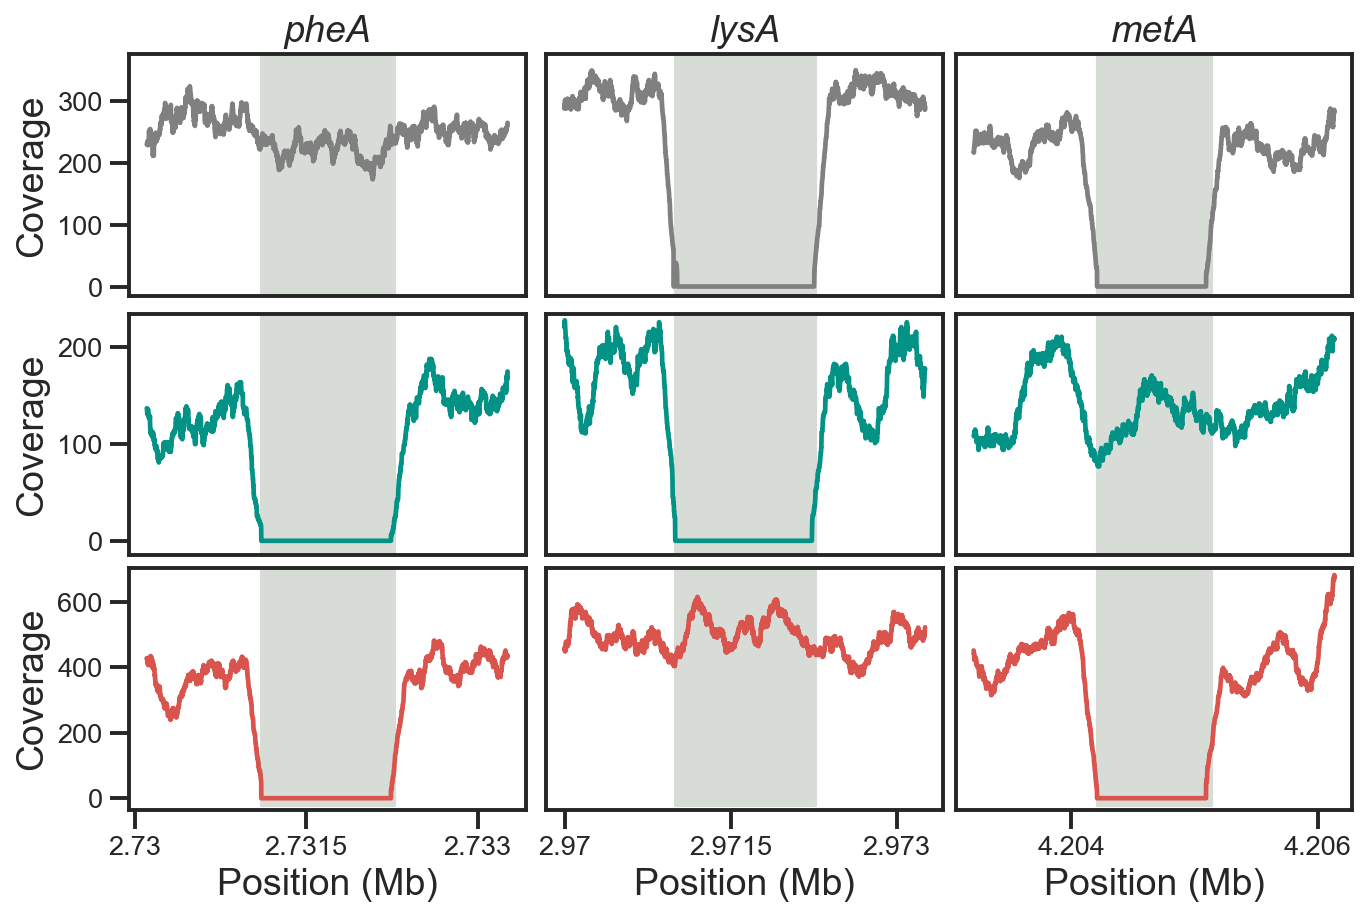

In [4]:
fig, axs = plt.subplots(3, 3, figsize=(9, 6),
                        constrained_layout=True)

i = 0
for strain, color in zip(['PM', 'PL', 'LM'][::-1],
                         ['xkcd:pale red',
                          'xkcd:teal',
                          'grey'][::-1]):
    for gene in ['pheA', 'lysA', 'metA']:
        gstart, gend = genes[gene]
        gstart = gstart / 1_000_000
        gend = gend / 1_000_000
        ax = axs.flat[i]
        t = df[(df['strain'] == strain) &
               (df['gene'] == gene)]
        ax.plot(t['pos'], t['cov'], '-', color=color,
                # lw=1.5,
                alpha=1)
        if strain == 'PM':
            ax.set_ylim(-35, 705)
            ax.fill_between([gstart, gend], [-20, -20], [750, 750],
                            color='xkcd:light grey',
                            zorder=-1)
            # ax.plot([gstart, gend], [325, 325], '--',
            #         color='xkcd:dark grey')
            ax.set_yticks([0, 200, 400, 600],
                          labels=[0, 200, 400, 600],
                          size=13)
            if gene == 'pheA':
                ax.set_xticks([2.730, 2.7315,
                               2.733],
                              labels=[2.730, 2.7315,
                               2.733],
                              size=13)
            elif gene == 'lysA':
                ax.set_xticks([2.970, 2.9715,
                               2.973],
                              labels=[2.970, 2.9715,
                               2.973],
                              size=13)
            elif gene == 'metA':
                ax.set_xticks([4.204, 4.206],
                              labels=[4.204, 4.206],
                              size=13)
            ax.set_xlabel('Position (Mb)')
        elif strain == 'PL':
            ax.set_ylim(-15, 235)
            ax.fill_between([gstart, gend], [-20, -20], [750, 750],
                            color='xkcd:light grey',
                            zorder=-1)
            # ax.plot([gstart, gend], [65, 65], '--',
            #         color='xkcd:dark grey')
            ax.set_xticks([])
            ax.set_yticks([0, 100, 200],
                          labels=[0, 100, 200],
                          size=13)
        elif strain == 'LM':
            ax.set_ylim(-15, 375)
            ax.fill_between([gstart, gend], [-20, -20], [750, 750],
                            color='xkcd:light grey',
                            zorder=-1)
            # ax.plot([gstart, gend], [130, 130], '--',
            #         color='xkcd:dark grey')
            ax.set_yticks([0, 100, 200, 300],
                          labels=[0, 100, 200, 300],
                          size=13)
            ax.set_title(gene, fontstyle='italic')
            ax.set_xticks([])
        if gene != 'pheA':
            ax.set_yticks([])
        else:
            ax.set_ylabel('Coverage')
        i += 1

plt.savefig('coverage_ancestrals.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('coverage_ancestrals.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);